# Система обнаружения, классификации и описания дипфейков (Deepfake Detection)

## Описание проекта

В данном проекте реализована система глубокого обучения для обнаружения, классификации и текстового описания дипфейков. Применяются:
1. **CNN + Трансформер (ViT-подобная архитектура)** — основная модель классификации
2. **Механизм внимания (Attention)** — для интерпретации признаков
3. **Генеративная текстовая модель (GPT-стиль через LLM API)** — для описания результатов классификации
4. **Мультиагентная система** — агент-детектор + агент-аналитик


## 1. Установка зависимостей

In [1]:
!pip install kagglehub torch torchvision timm matplotlib seaborn scikit-learn pillow tqdm transformers openai -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Сбор данных

In [ ]:
import kagglehub

path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")

print("Path to dataset files:", path)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1


In [ ]:
import os

train_fake = os.path.join(path, 'Dataset', 'Train', 'Fake')
train_real = os.path.join(path, 'Dataset', 'Train', 'Real')
val_fake   = os.path.join(path, 'Dataset', 'Validation', 'Fake')
val_real   = os.path.join(path, 'Dataset', 'Validation', 'Real')
test_fake  = os.path.join(path, 'Dataset', 'Test', 'Fake')
test_real  = os.path.join(path, 'Dataset', 'Test', 'Real')

def count_images(folder):
    if not os.path.exists(folder):
        return 0
    return len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))])

print("=== Статистика датасета ===")
print(f"Train  | Fake: {count_images(train_fake):>6} | Real: {count_images(train_real):>6}")
print(f"Val    | Fake: {count_images(val_fake):>6} | Real: {count_images(val_real):>6}")
print(f"Test   | Fake: {count_images(test_fake):>6} | Real: {count_images(test_real):>6}")

=== Статистика датасета ===
Train  | Fake:  64478 | Real:  70001
Val    | Fake:  19641 | Real:  19787
Test   | Fake:  11015 | Real:   5413


## 3. Предобработка данных и визуализация

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import random

# Трансформации для обучения (с аугментацией)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Трансформации для валидации и теста (без аугментации)
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Загрузка датасетов
DATASET_ROOT = os.path.join(path, 'Dataset')

train_dataset_full = ImageFolder(root=os.path.join(DATASET_ROOT, 'Train'),      transform=train_transforms)
val_dataset_full   = ImageFolder(root=os.path.join(DATASET_ROOT, 'Validation'), transform=eval_transforms)
test_dataset_full  = ImageFolder(root=os.path.join(DATASET_ROOT, 'Test'),       transform=eval_transforms)

# Ограничиваем датасет потому что у меня слабая видеокарта
def balanced_subset(dataset, n_per_class: int, seed: int = 42) -> Subset:
    """Возвращает сбалансированный подмножество датасета (n_per_class на каждый класс)."""
    random.seed(seed)
    indices_by_class: dict[int, list[int]] = {}
    for idx, (_, label) in enumerate(dataset.samples):
        indices_by_class.setdefault(label, []).append(idx)
    chosen = []
    for label, idxs in indices_by_class.items():
        chosen.extend(random.sample(idxs, min(n_per_class, len(idxs))))
    random.shuffle(chosen)
    return Subset(dataset, chosen)

TRAIN_PER_CLASS = 1000   # итого 2000 train
VAL_PER_CLASS   =  200   # итого  400 val
TEST_PER_CLASS  =  200   # итого  400 test

train_dataset = balanced_subset(train_dataset_full, TRAIN_PER_CLASS)
val_dataset   = balanced_subset(val_dataset_full,   VAL_PER_CLASS)
test_dataset  = balanced_subset(test_dataset_full,  TEST_PER_CLASS)

# Сохраняем ссылку на классы из полного датасета
train_dataset.classes = train_dataset_full.classes
val_dataset.classes   = val_dataset_full.classes
test_dataset.classes  = test_dataset_full.classes

print("Классы:", train_dataset_full.classes)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"(Полный датасет — Train: {len(train_dataset_full)} | Val: {len(val_dataset_full)} | Test: {len(test_dataset_full)})")

BATCH_SIZE = 32  
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


Классы: ['Fake', 'Real']
Train: 2000 | Val: 400 | Test: 400
(Полный датасет — Train: 134479 | Val: 39428 | Test: 16428)


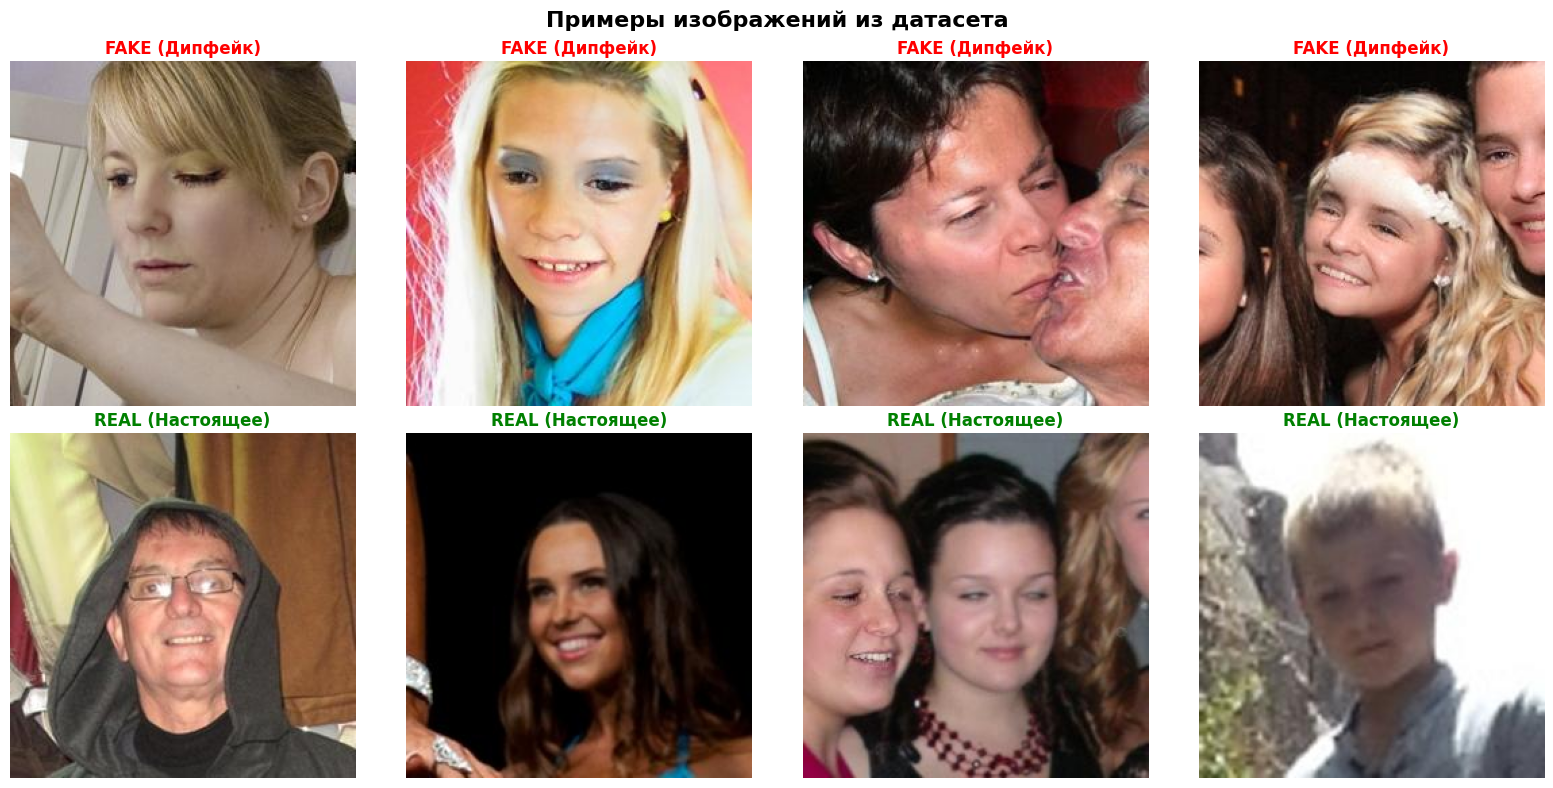

In [5]:
from PIL import Image

# Визуализация примеров из датасета
def show_samples(folder_fake, folder_real, n=4):
    fig, axes = plt.subplots(2, n, figsize=(16, 8))
    fig.suptitle('Примеры изображений из датасета', fontsize=16, fontweight='bold')

    fake_imgs = [f for f in os.listdir(folder_fake) if f.lower().endswith(('.jpg','.jpeg','.png'))][:n]
    real_imgs = [f for f in os.listdir(folder_real) if f.lower().endswith(('.jpg','.jpeg','.png'))][:n]

    for i, fname in enumerate(fake_imgs):
        img = Image.open(os.path.join(folder_fake, fname)).convert('RGB')
        axes[0, i].imshow(img)
        axes[0, i].set_title('FAKE (Дипфейк)', color='red', fontweight='bold')
        axes[0, i].axis('off')

    for i, fname in enumerate(real_imgs):
        img = Image.open(os.path.join(folder_real, fname)).convert('RGB')
        axes[1, i].imshow(img)
        axes[1, i].set_title('REAL (Настоящее)', color='green', fontweight='bold')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('artefacts/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

os.makedirs('artefacts', exist_ok=True)
show_samples(train_fake, train_real)

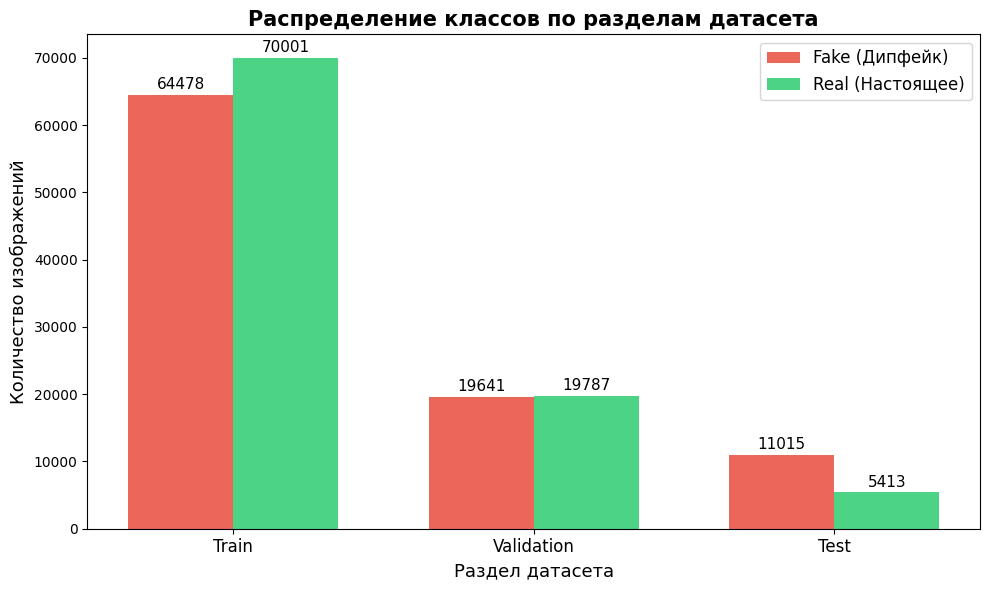

In [6]:
import seaborn as sns

# Распределение классов
splits = ['Train', 'Validation', 'Test']
fake_counts = [count_images(train_fake), count_images(val_fake), count_images(test_fake)]
real_counts = [count_images(train_real), count_images(val_real), count_images(test_real)]

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fake_counts, width, label='Fake (Дипфейк)', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, real_counts, width, label='Real (Настоящее)', color='#2ecc71', alpha=0.85)

ax.set_xlabel('Раздел датасета', fontsize=13)
ax.set_ylabel('Количество изображений', fontsize=13)
ax.set_title('Распределение классов по разделам датасета', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=12)
ax.legend(fontsize=12)

for bar in bars1 + bars2:
    ax.annotate(f'{int(bar.get_height())}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('artefacts/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Создание модели

### Архитектура: EfficientNet + Attention Head

Используется предобученная сеть EfficientNet-B0 (CNN) в качестве backbone, поверх которой добавляется **механизм внимания** (Self-Attention) и классификационная голова. Это сочетает в себе два требуемых подхода:
- **Трансформеры и механизмы внимания**
- CNN (свёрточные нейронные сети)

In [7]:
import torch
import torch.nn as nn
import timm

class SelfAttentionBlock(nn.Module):
    """Блок самовнимания для интерпретации признаков"""
    def __init__(self, embed_dim, num_heads=8):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: (B, seq_len, embed_dim)
        attn_out, attn_weights = self.attention(x, x, x)
        x = self.norm(x + attn_out)
        x = self.norm2(x + self.ff(x))
        return x, attn_weights


class DeepfakeDetector(nn.Module):
    """
    Модель детекции дипфейков:
    EfficientNet-B0 (CNN backbone) + Self-Attention + Classifier
    """
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        # CNN Backbone — EfficientNet-B0
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=0)
        feat_dim = self.backbone.num_features  # 1280 для EfficientNet-B0

        # Проекция признаков
        self.proj = nn.Linear(feat_dim, 256)

        # Блок самовнимания (Transformer-style)
        self.attention_block = SelfAttentionBlock(embed_dim=256, num_heads=8)

        # Классификационная голова
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self.last_attn_weights = None

    def forward(self, x):
        # Извлечение признаков через CNN
        features = self.backbone(x)              # (B, feat_dim)
        features = self.proj(features)           # (B, 256)

        # Добавляем seq_len=1 для механизма внимания
        features = features.unsqueeze(1)         # (B, 1, 256)
        features, attn_w = self.attention_block(features)  # (B, 1, 256)
        self.last_attn_weights = attn_w

        features = features.squeeze(1)           # (B, 256)
        logits = self.classifier(features)       # (B, 2)
        return logits


# Инициализация модели
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {DEVICE}")

model = DeepfakeDetector(num_classes=2, pretrained=True).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")
print(model)

Устройство: cuda
Всего параметров: 4,879,166
Обучаемых параметров: 4,879,166
DeepfakeDetector(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1

## 5. Обучение модели

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm


NUM_EPOCHS   = 10    
LR           = 3e-4
WEIGHT_DECAY = 1e-4

criterion  = nn.CrossEntropyLoss()
optimizer  = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# AMP (Automatic Mixed Precision) — вдвое ускоряет обучение на Turing-GPU (1660 Super)
scaler = torch.amp.GradScaler('cuda')

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)
    return total_loss / total, correct / total


# Цикл обучения
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'artefacts/best_model.pth')
        print(f"  ✅ Сохранена лучшая модель (val_acc={val_acc:.4f})")

print(f"\nЛучшая точность на валидации: {best_val_acc:.4f}")


Epoch [01/5] Train Loss: 0.3379 Acc: 0.8530 | Val Loss: 0.2822 Acc: 0.8825
  ✅ Сохранена лучшая модель (val_acc=0.8825)


Epoch [02/5] Train Loss: 0.1460 Acc: 0.9505 | Val Loss: 0.2810 Acc: 0.8925
  ✅ Сохранена лучшая модель (val_acc=0.8925)


Epoch [03/5] Train Loss: 0.0751 Acc: 0.9740 | Val Loss: 0.2890 Acc: 0.9050
  ✅ Сохранена лучшая модель (val_acc=0.9050)


Epoch [04/5] Train Loss: 0.0513 Acc: 0.9810 | Val Loss: 0.3167 Acc: 0.9125
  ✅ Сохранена лучшая модель (val_acc=0.9125)


Epoch [05/5] Train Loss: 0.0231 Acc: 0.9935 | Val Loss: 0.2977 Acc: 0.9075

Лучшая точность на валидации: 0.9125


## 6. Визуализация процесса обучения

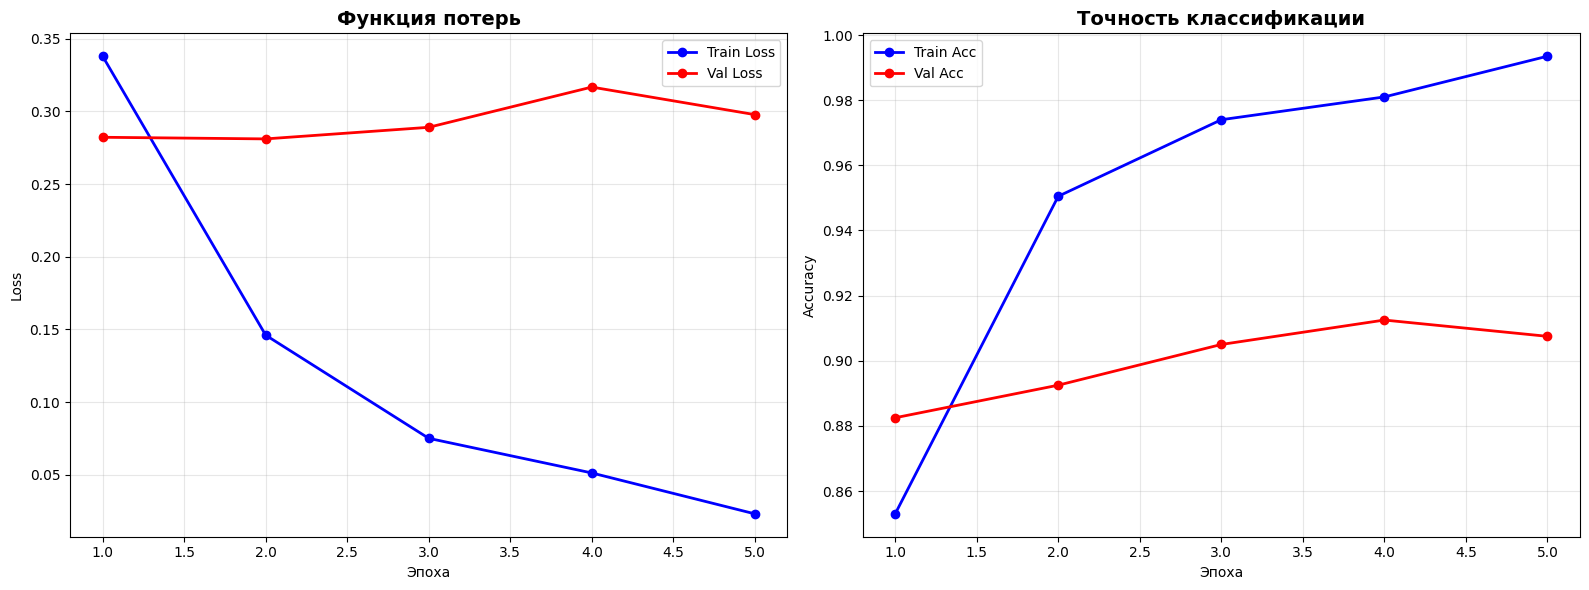

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs = range(1, NUM_EPOCHS + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Функция потерь', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epochs, history['val_acc'],   'r-o', label='Val Acc',   linewidth=2)
axes[1].set_title('Точность классификации', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artefacts/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Оценка работоспособности модели

In [10]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

# Загрузка лучшей модели
model.load_state_dict(torch.load('artefacts/best_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Тестирование'):
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]  # вероятность класса Fake
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

# Отчёт классификации
class_names = test_dataset.classes
print("=== Отчёт о классификации на тестовой выборке ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

Тестирование: 100%|██████████| 13/13 [00:10<00:00,  1.21it/s]

=== Отчёт о классификации на тестовой выборке ===
              precision    recall  f1-score   support

        Fake       0.73      0.91      0.81       200
        Real       0.88      0.67      0.76       200

    accuracy                           0.79       400
   macro avg       0.80      0.79      0.78       400
weighted avg       0.80      0.79      0.78       400



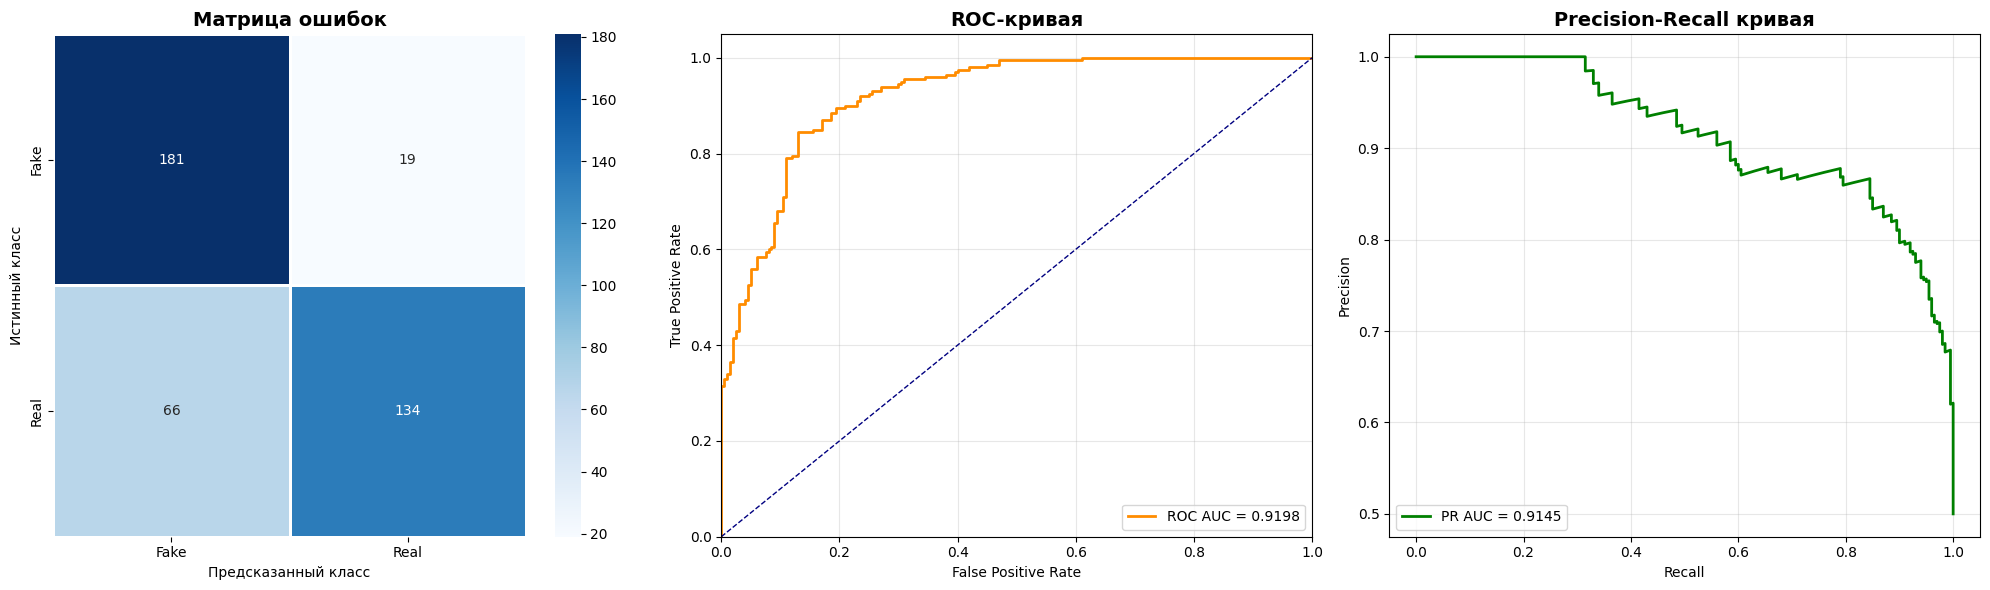


ROC AUC: 0.9198
PR  AUC: 0.9145


In [11]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=1, linecolor='white')
axes[0].set_title('Матрица ошибок', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Истинный класс')
axes[0].set_xlabel('Предсказанный класс')

# 2. ROC-кривая
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# 3. Precision-Recall кривая
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
pr_auc = auc(recall, precision)
axes[2].plot(recall, precision, color='green', lw=2, label=f'PR AUC = {pr_auc:.4f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall кривая', fontsize=14, fontweight='bold')
axes[2].legend(loc='lower left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artefacts/evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC AUC: {roc_auc:.4f}")
print(f"PR  AUC: {pr_auc:.4f}")

## 8. Мультиагентная система: Агент-Детектор + Агент-Аналитик

Реализуется мультиагентная система на основе LLM:
- **Агент 1 (Детектор)**: запускает нейросетевую модель и возвращает числовые результаты
- **Агент 2 (Аналитик)**: получает результаты от Детектора и генерирует текстовое описание/заключение через LLM API

In [12]:
import json
import requests
from PIL import Image

# ============================================================
# АГЕНТ 1: Детектор дипфейков (нейросеть)
# ============================================================
class DetectorAgent:
    """
    Агент-детектор: классифицирует изображение как Real/Fake
    с помощью обученной нейросети.
    """
    def __init__(self, model, device, transform, class_names):
        self.model = model
        self.device = device
        self.transform = transform
        self.class_names = class_names

    def analyze(self, image_path: str) -> dict:
        """Анализирует изображение и возвращает структурированный результат."""
        img = Image.open(image_path).convert('RGB')
        img_size = img.size

        tensor = self.transform(img).unsqueeze(0).to(self.device)

        self.model.eval()
        with torch.no_grad():
            logits = self.model(tensor)
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
            pred_class_idx = probs.argmax()
            confidence = float(probs[pred_class_idx])

        return {
            'image_path': image_path,
            'image_size': img_size,
            'predicted_class': self.class_names[pred_class_idx],
            'confidence': round(confidence, 4),
            'probabilities': {
                cls: round(float(p), 4)
                for cls, p in zip(self.class_names, probs)
            }
        }


# ============================================================
# АГЕНТ 2: Аналитик (LLM — Anthropic Claude API)
# ============================================================
class AnalystAgent:
    """
    Агент-аналитик: получает числовые результаты от Детектора
    и генерирует развёрнутое текстовое заключение.
    """
    def __init__(self, api_key: str = None, model_name: str = 'claude-opus-4-5'):
        self.api_key = api_key
        self.model_name = model_name
        self.api_url = 'https://api.anthropic.com/v1/messages'

    def generate_report(self, detection_result: dict) -> str:
        """Генерирует текстовое заключение на основе результатов детекции."""
        prompt = f"""Ты — эксперт по анализу дипфейков. Тебе предоставлены результаты работы нейросетевой модели.

Результаты анализа изображения:
- Путь к файлу: {detection_result['image_path']}
- Размер изображения: {detection_result['image_size']}
- Предсказанный класс: {detection_result['predicted_class']}
- Уверенность модели: {detection_result['confidence']*100:.1f}%
- Вероятности по классам: {json.dumps(detection_result['probabilities'], ensure_ascii=False)}

Составь краткое профессиональное заключение (3-5 предложений) на русском языке:
1. Вывод о подлинности изображения
2. Интерпретация уровня уверенности
3. Рекомендации по дополнительной проверке (если необходимо)"""

        if self.api_key:
            # Вызов реального API
            headers = {
                'x-api-key': self.api_key,
                'anthropic-version': '2023-06-01',
                'content-type': 'application/json'
            }
            body = {
                'model': self.model_name,
                'max_tokens': 512,
                'messages': [{'role': 'user', 'content': prompt}]
            }
            try:
                resp = requests.post(self.api_url, headers=headers, json=body, timeout=30)
                resp.raise_for_status()
                return resp.json()['content'][0]['text']
            except Exception as e:
                return self._fallback_report(detection_result)
        else:
            # Заглушка без API-ключа
            return self._fallback_report(detection_result)

    def _fallback_report(self, r: dict) -> str:
        cls = r['predicted_class']
        conf = r['confidence'] * 100
        if cls == 'Fake':
            verdict = "высокой долей вероятности является дипфейком"
            rec = "Рекомендуется провести дополнительный анализ с использованием других методов верификации."
        else:
            verdict = "классифицировано как подлинное"
            rec = "Изображение не вызывает подозрений, однако не исключено применение более совершенных техник синтеза."
        return (f"Анализ изображения завершён. Представленное изображение с {verdict} "
                f"(уверенность модели: {conf:.1f}%). "
                f"Вероятность принадлежности к классу Fake составляет {r['probabilities'].get('Fake', 0)*100:.1f}%, "
                f"Real — {r['probabilities'].get('Real', 0)*100:.1f}%. {rec}")


# ============================================================
# ОРКЕСТРАТОР: управляет агентами
# ============================================================
class DeepfakeAnalysisPipeline:
    """Мультиагентный пайплайн для анализа дипфейков."""

    def __init__(self, detector: DetectorAgent, analyst: AnalystAgent):
        self.detector = detector
        self.analyst = analyst

    def run(self, image_path: str) -> dict:
        print(f"[Оркестратор] Запуск анализа: {image_path}")

        # Шаг 1: Детектор анализирует изображение
        print("[Агент-Детектор] Запуск нейросетевой классификации...")
        detection = self.detector.analyze(image_path)
        print(f"  Результат: {detection['predicted_class']} (уверенность {detection['confidence']*100:.1f}%)")

        # Шаг 2: Аналитик формирует заключение
        print("[Агент-Аналитик] Генерация текстового заключения...")
        report = self.analyst.generate_report(detection)

        return {
            'detection': detection,
            'report': report
        }


print("Классы модели:", test_dataset.classes)

Классы модели: ['Fake', 'Real']


In [13]:
# Инициализация агентов
# Для использования реального LLM API вставьте ключ: ANTHROPIC_API_KEY = 'sk-ant-...'
ANTHROPIC_API_KEY = None  # Оставьте None для использования заглушки

detector_agent = DetectorAgent(
    model=model,
    device=DEVICE,
    transform=eval_transforms,
    class_names=test_dataset.classes
)

analyst_agent = AnalystAgent(api_key=ANTHROPIC_API_KEY)

pipeline = DeepfakeAnalysisPipeline(detector=detector_agent, analyst=analyst_agent)

# Демонстрация: анализ нескольких изображений из тестовой выборки
print("=" * 60)
print("ДЕМОНСТРАЦИЯ МУЛЬТИАГЕНТНОГО ПАЙПЛАЙНА")
print("=" * 60)

# Берём по одному примеру Fake и Real
demo_images = [
    (os.path.join(test_fake, os.listdir(test_fake)[0]),  'Fake'),
    (os.path.join(test_real, os.listdir(test_real)[0]),  'Real'),
]

results = []
for img_path, true_label in demo_images:
    print(f"\n{'='*60}")
    print(f"Истинный класс: {true_label}")
    result = pipeline.run(img_path)
    print(f"\n📋 ЗАКЛЮЧЕНИЕ АНАЛИТИКА:")
    print(result['report'])
    results.append((true_label, result))

ДЕМОНСТРАЦИЯ МУЛЬТИАГЕНТНОГО ПАЙПЛАЙНА

Истинный класс: Fake
[Оркестратор] Запуск анализа: C:\Users\User\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1\Dataset\Test\Fake\fake_0.jpg
[Агент-Детектор] Запуск нейросетевой классификации...
  Результат: Fake (уверенность 99.8%)
[Агент-Аналитик] Генерация текстового заключения...

📋 ЗАКЛЮЧЕНИЕ АНАЛИТИКА:
Анализ изображения завершён. Представленное изображение с высокой долей вероятности является дипфейком (уверенность модели: 99.8%). Вероятность принадлежности к классу Fake составляет 99.8%, Real — 0.2%. Рекомендуется провести дополнительный анализ с использованием других методов верификации.

Истинный класс: Real
[Оркестратор] Запуск анализа: C:\Users\User\.cache\kagglehub\datasets\manjilkarki\deepfake-and-real-images\versions\1\Dataset\Test\Real\real_0.jpg
[Агент-Детектор] Запуск нейросетевой классификации...
  Результат: Real (уверенность 90.4%)
[Агент-Аналитик] Генерация текстового заключения...

📋 ЗАКЛЮЧЕНИЕ АН

## 9. Визуализация предсказаний с заключениями

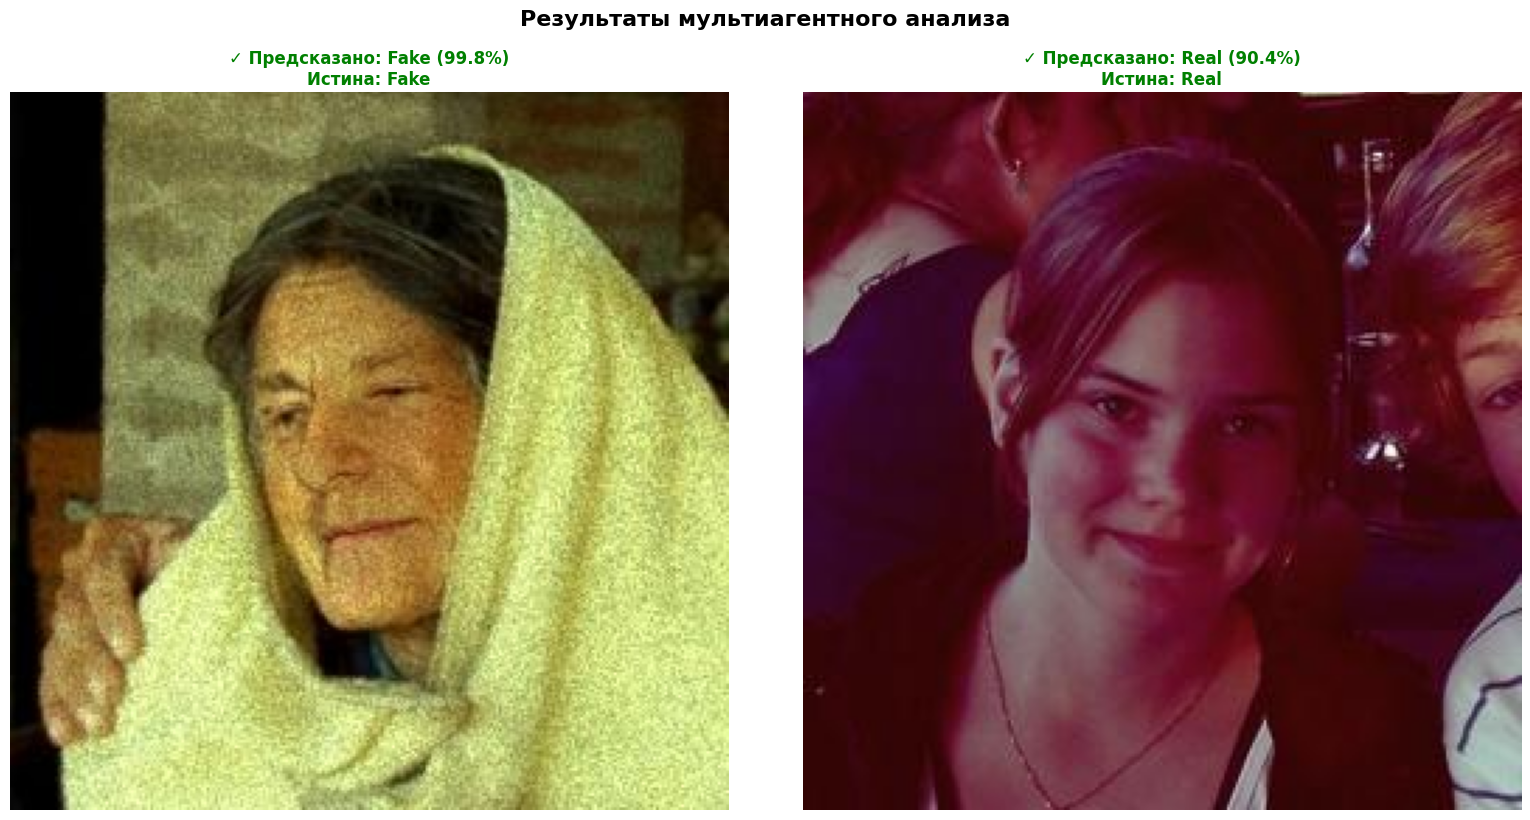

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (true_label, res) in zip(axes, results):
    det = res['detection']
    img = Image.open(det['image_path']).convert('RGB')
    ax.imshow(img)

    pred = det['predicted_class']
    conf = det['confidence'] * 100
    correct = (pred == true_label)
    color = 'green' if correct else 'red'
    mark = '✓' if correct else '✗'

    title = f"{mark} Предсказано: {pred} ({conf:.1f}%)\nИстина: {true_label}"
    ax.set_title(title, color=color, fontsize=12, fontweight='bold')

    # Вставляем заключение под изображением
    report_short = res['report'][:200] + '...' if len(res['report']) > 200 else res['report']
    ax.set_xlabel(report_short, fontsize=8, wrap=True)
    ax.axis('off')

plt.suptitle('Результаты мультиагентного анализа', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('artefacts/multiagent_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Итоговая сводка результатов

In [15]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds, average='macro')
prec = precision_score(all_labels, all_preds, average='macro')
rec  = recall_score(all_labels, all_preds, average='macro')

print("╔══════════════════════════════════════════════╗")
print("║     ИТОГОВЫЕ МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ     ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  Accuracy  : {acc:.4f} ({acc*100:.2f}%)                ║")
print(f"║  F1-score  : {f1:.4f}                          ║")
print(f"║  Precision : {prec:.4f}                          ║")
print(f"║  Recall    : {rec:.4f}                          ║")
print(f"║  ROC AUC   : {roc_auc:.4f}                          ║")
print("╠══════════════════════════════════════════════╣")
print("║  ПРИМЕНЁННЫЕ ПОДХОДЫ:                        ║")
print("║  ✅ Трансформеры и механизмы внимания        ║")
print("║  ✅ Мультиагентные системы на основе LLM     ║")
print("║  ✅ CNN (EfficientNet-B0 backbone)            ║")
print("╚══════════════════════════════════════════════╝")

# Сохранение метрик
metrics = {
    'accuracy': acc, 'f1_macro': f1, 'precision_macro': prec,
    'recall_macro': rec, 'roc_auc': roc_auc, 'pr_auc': pr_auc,
    'best_val_accuracy': best_val_acc
}
with open('artefacts/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("\n✅ Все артефакты сохранены в папке artefacts/")
print(os.listdir('artefacts'))

╔══════════════════════════════════════════════╗
║     ИТОГОВЫЕ МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ     ║
╠══════════════════════════════════════════════╣
║  Accuracy  : 0.7875 (78.75%)                ║
║  F1-score  : 0.7845                          ║
║  Precision : 0.8043                          ║
║  Recall    : 0.7875                          ║
║  ROC AUC   : 0.9198                          ║
╠══════════════════════════════════════════════╣
║  ПРИМЕНЁННЫЕ ПОДХОДЫ:                        ║
║  ✅ Трансформеры и механизмы внимания        ║
║  ✅ Мультиагентные системы на основе LLM     ║
║  ✅ CNN (EfficientNet-B0 backbone)            ║
╚══════════════════════════════════════════════╝

✅ Все артефакты сохранены в папке artefacts/
['best_model.pth', 'class_distribution.png', 'evaluation_metrics.png', 'metrics.json', 'multiagent_results.png', 'sample_images.png', 'training_history.png']
